(30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2          

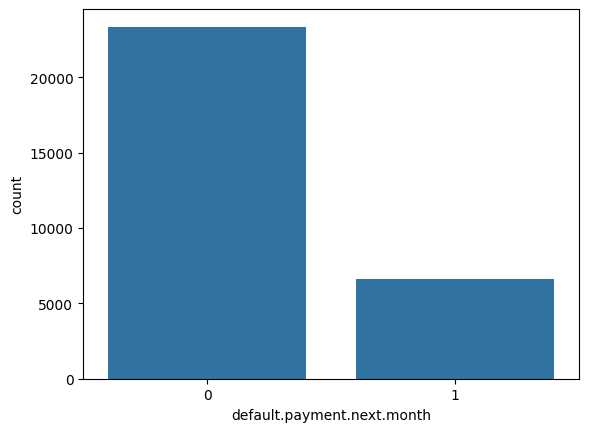

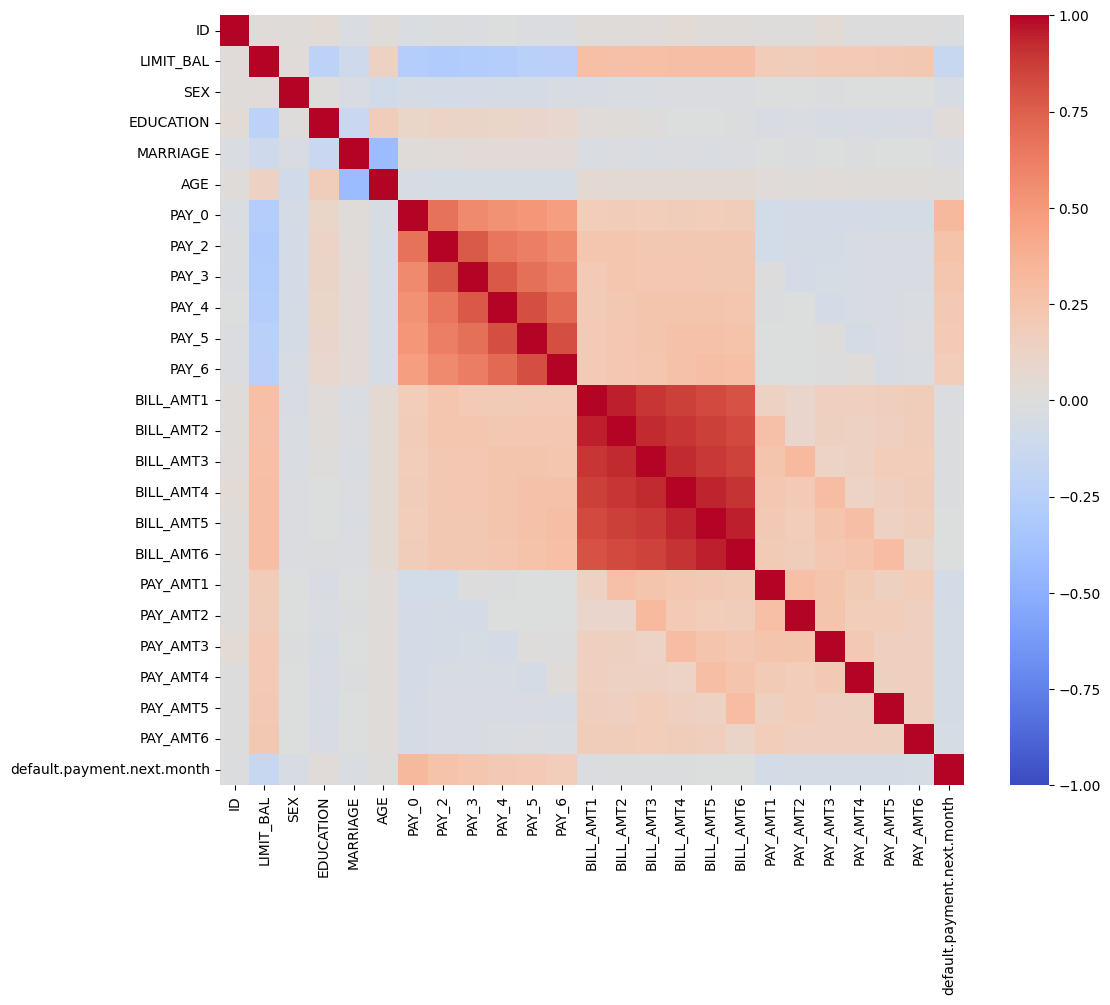

In [2]:
# %%
# Title: Credit Card Default Prediction - EDA & Modelling
# --- cell ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


# --- cell ---
# Load dataset (update path if necessary)
# Use a raw string or forward slashes to avoid unicode escape errors on Windows paths
csv_path = r'C:\Users\kumar\Desktop\Projects\Credit-Card-Pulse\Dataset\UCI_Credit_Card.csv'
df = pd.read_csv(csv_path)
df.head()


# --- cell ---
# Basic EDA
print(df.shape)
print(df.info())
print(df.describe())


# --- cell ---
# Target distribution
sns.countplot(x='default.payment.next.month', data=df)


# --- cell ---
# Correlations heatmap (careful with many features)
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', vmin=-1, vmax=1)


# --- cell ---
# Preprocessing & feature engineering (example)
# - create age groups, payment delinquencies summary, ratio features, etc.


# --- cell ---
# Model training example: use RandomForest in a pipeline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


X = df.drop(columns=['default.payment.next.month','ID'] if 'ID' in df.columns else ['default.payment.next.month'])
y = df['default.payment.next.month']


X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


clf = Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(n_estimators=200, random_state=42))])
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


# --- cell ---
# Save model with joblib
import joblib
os.makedirs('models', exist_ok=True)
joblib.dump(clf, 'models/model.pkl')


# --- cell ---
# Quick test: load model and predict on single sample
m = joblib.load('models/model.pkl')
print(m.predict_proba(X_test.iloc[:3])[:,1])